# LAB 04: KEYPOINT DETECTION


1. Khai báo thư viện ảnh

In [ ]:
import numpy as np
import cv2
from skimage.feature import blob_log
from matplotlib import pyplot as hung
from sklearn.cluster import KMeans

Kiểm tra opencv đọc ảnh và đặt ảnh cho đúng hiển thị ban đầu

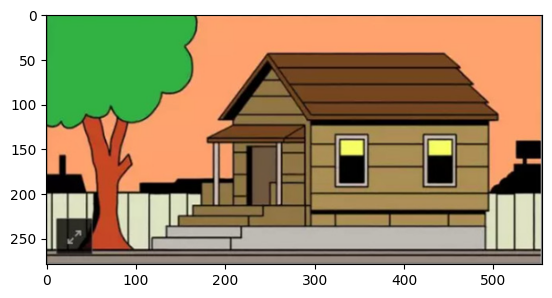

In [ ]:
img = cv2.imread('image.png')
hung.imshow(img[:,:,::-1]) 


2. Sử dụng Harris Corner Detection tìm các keypoint trong ảnh. 
- Máy dò góc Harris trong OpenCV


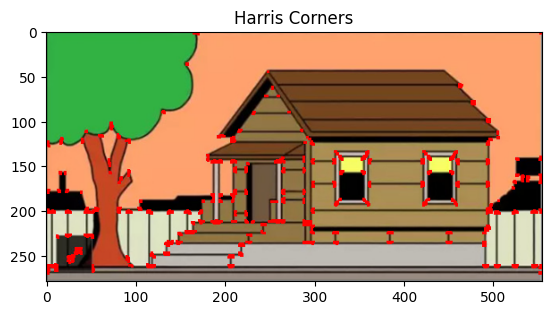

In [ ]:
import numpy as np
import cv2 as cv
filename = 'image.png'
img = cv.imread(filename)
gray = cv.cvtColor(img,cv.COLOR_BGR2GRAY)
gray = np.float32(gray)
dst = cv.cornerHarris(gray,2,3,0.04)
#result is dilated for marking the corners, not important
dst = cv.dilate(dst,None)
# Threshold for an optimal value, it may vary depending on the image.
img[dst>0.01*dst.max()]=[0,0,255]
hung.title("Harris Corners")
hung.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
hung.show()

3. Sử dụng Band-pass filtering by Difference of Gaussians

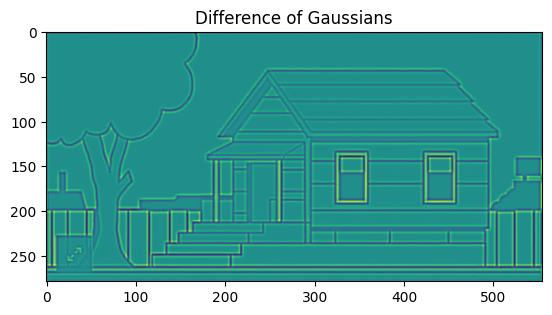

In [ ]:
blur1 = cv2.GaussianBlur(gray,(5,5),1)
blur2 = cv2.GaussianBlur(gray,(5,5),2)
DoG = blur1 - blur2
hung.imshow(DoG)
hung.title("Difference of Gaussians")
hung.show()

4. Kiểm tra ảnh qua Automatic Scale Selection 

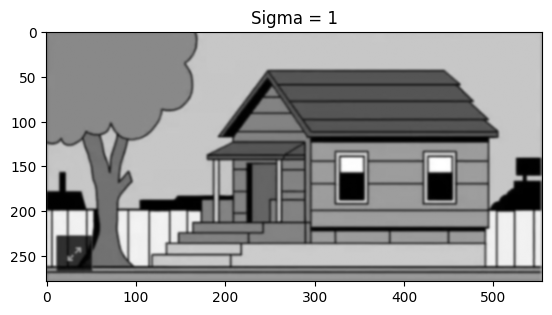

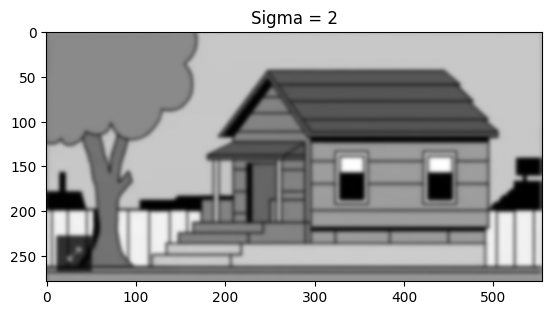

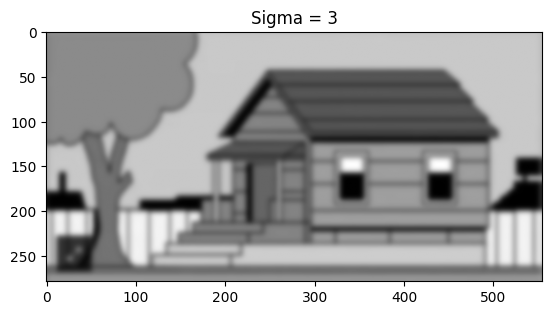

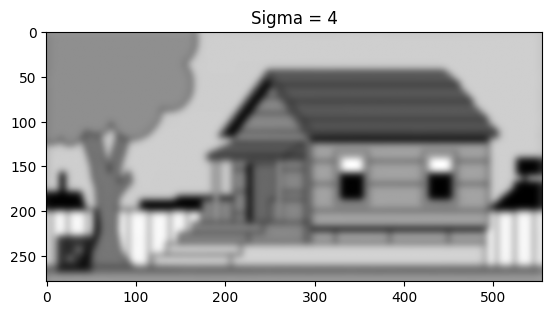

In [ ]:
s = [1,2,3,4]

for i in s:
    blur = cv2.GaussianBlur(gray,(0,0),i)
    hung.imshow(blur,cmap='gray')
    hung.title(f"Sigma = {i}")
    hung.show()

5. Kiểm tra ảnh qua Scale Invariant Detection



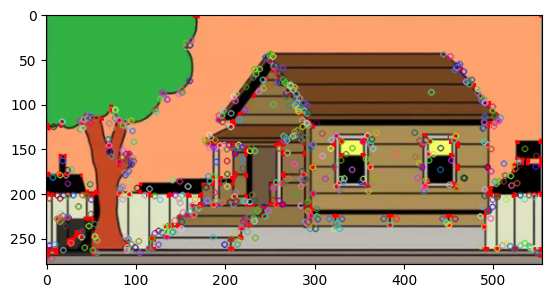

In [ ]:
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
sift = cv2.SIFT_create()
kp, des = sift.detectAndCompute(gray, None)
img_sift = cv2.drawKeypoints(img, kp, None)

hung.imshow(img_sift[:,:,::-1])
hung.show()

6. Kiểm tra ảnh qua Scale-space blob detector. 


Text(0.5, 1.0, 'Blob detection')

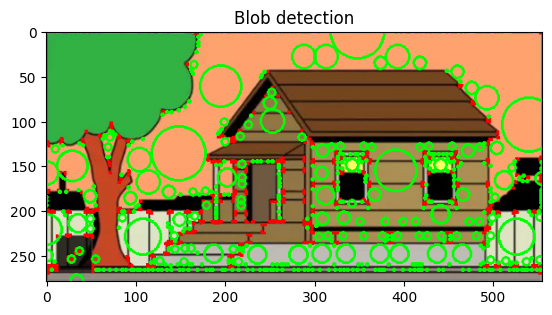

In [ ]:
blobs = blob_log(gray, max_sigma=30, num_sigma=10, threshold=.1)
img_blob = img.copy()

for y,x,r in blobs:
    cv2.circle(img_blob,(int(x),int(y)),int(r),(0,255,0),2)

hung.imshow(img_blob[:,:,::-1])
hung.title("Blob detection")


7. Thực hành với Bag-of-words detection


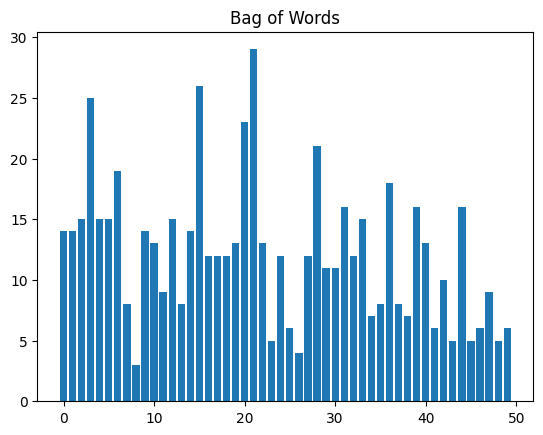

In [ ]:
k = 50 # số visual words

kmeans = KMeans(n_clusters=k)
kmeans.fit(des)

visual_words = kmeans.predict(des)
# tạo histogram
histogram = np.zeros(k)

for w in visual_words:
    histogram[w] += 1
hung.bar(range(k), histogram)
hung.title("Bag of Words")
hung.show()

8. Ghép ảnh Image Panoramas


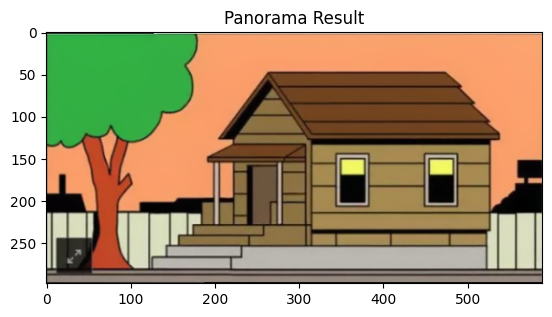

In [ ]:
img1 = cv2.imread("image2.png")
img2 = cv2.imread("image3.png")

stitcher = cv2.Stitcher_create()

status, pano = stitcher.stitch([img1, img2])

hung.imshow(pano[:,:,::-1])
hung.title("Panorama Result")
hung.show()

9. Ghép ảnh Automatic mosaicing 


Text(0.5, 1.0, 'Automatic Mosaicing Result')

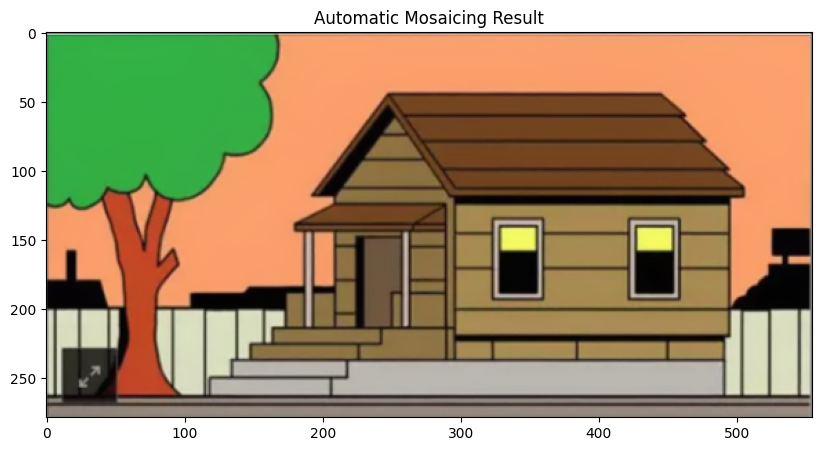

In [ ]:
# đọc nhiều ảnh
img1 = cv2.imread("image.png")
img2 = cv2.imread("image2.png")
img3 = cv2.imread("image3.png")

images = [img1, img2, img3]

# tạo stitcher
stitcher = cv2.Stitcher_create()
status, mosaic = stitcher.stitch(images)

status == cv2.Stitcher_OK
hung.figure(figsize=(10,5))
hung.imshow(mosaic[:,:,::-1])
hung.title("Automatic Mosaicing Result")


10. Sử dụng Wide base-line stereo


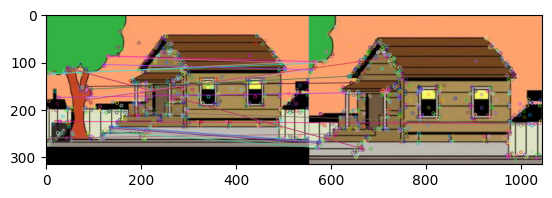

In [ ]:
sift = cv2.SIFT_create()

kp1,des1 = sift.detectAndCompute(img1,None)
kp2,des2 = sift.detectAndCompute(img2,None)

bf = cv2.BFMatcher()

matches = bf.knnMatch(des1,des2,k=2)

good=[]

for m,n in matches:
    if m.distance < 0.75*n.distance:
        good.append(m)

img_stereo = cv2.drawMatches(img1,kp1,img2,kp2,good[:20],None)

hung.imshow(img_stereo[:,:,::-1])
hung.show()

11. CBIR (content-based image retrieval)


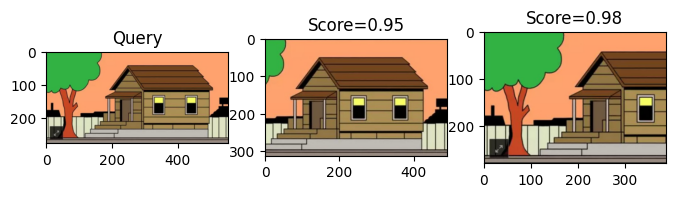

In [ ]:
import cv2
import numpy as np
from matplotlib import pyplot as hung

img1 = cv2.imread("image2.png")
img2 = cv2.imread("image3.png")
query = cv2.imread("image.png")

def hist(img):
    h = cv2.calcHist([img],[0,1,2],None,[8,8,8],[0,256,0,256,0,256])
    return cv2.normalize(h,h).flatten()

hq = hist(query)

score1 = cv2.compareHist(hq, hist(img1), cv2.HISTCMP_CORREL)
score2 = cv2.compareHist(hq, hist(img2), cv2.HISTCMP_CORREL)

hung.figure(figsize=(8,3))

hung.subplot(1,3,1)
hung.imshow(query[:,:,::-1])
hung.title("Query")

hung.subplot(1,3,2)
hung.imshow(img1[:,:,::-1])
hung.title(f"Score={score1:.2f}")

hung.subplot(1,3,3)
hung.imshow(img2[:,:,::-1])
hung.title(f"Score={score2:.2f}")

hung.show()

12. Bag-of-word with SIFT + Histogram

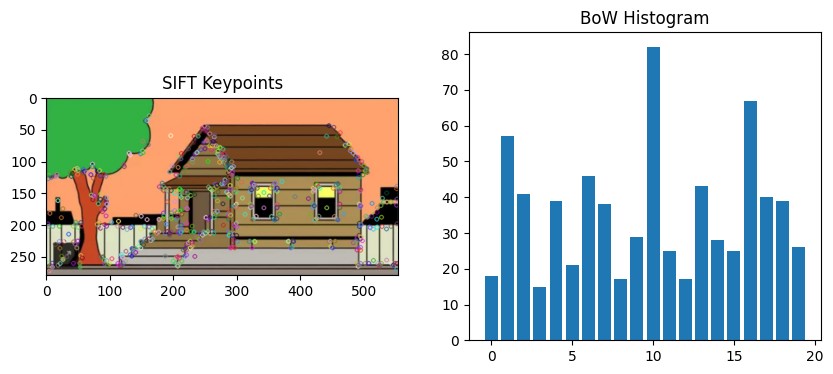

In [105]:
import cv2
import numpy as np
from sklearn.cluster import KMeans
from matplotlib import pyplot as hung

img = cv2.imread("image.png")
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# SIFT
sift = cv2.SIFT_create()
kp, des = sift.detectAndCompute(gray,None)

# hiển thị keypoints
img_kp = cv2.drawKeypoints(img,kp,None)

# KMeans
k = 20
kmeans = KMeans(n_clusters=k).fit(des)

words = kmeans.predict(des)

hist = np.bincount(words, minlength=k)

# show
hung.figure(figsize=(10,4))
hung.subplot(1,2,1)
hung.imshow(img_kp[:,:,::-1])
hung.title("SIFT Keypoints")
hung.subplot(1,2,2)
hung.bar(range(k), hist)
hung.title("BoW Histogram")
hung.show()